# Aprendizaje Estadístico y Data Mining

## Práctica 2: Clasificador de crímenes

### Objetivo
La ciudad de San Francisco es famosa entre otras cosas por la proliferación de empresas del ámbito tecnológico. Esto ha llevado a una profunda desigualdad entre sus habitantes, por lo que la proliferación de crímenes ha aumentado. Es por ello qué se quiere construir un clasificador que proporcione una serie de reglas de manera que se pueda saber que crímenes se van a cometer teniendo en cuenta el momento del día (noche de 0:00 a 7:59, mañana de 8:00 a 15:59 y tarde de 16:00 a 23:59), día de la semana y distrito. Muestra todos los resultados del algoritmo paso a paso.

Para ello usaremos el dataset **“sf_crimenes.csv”** que se encuentra en Moodle. Elige el clasificador que más se adapte de entre los vistos en clase y usa *scikit-learn* junto con las librerías que necesites para resolver las siguientes cuestiones.

* [Link al dataset.](./data/sf_crimenes.csv)

**Enunciado:**  Crea un clasificador en el que uses al menos dos criterios de división distintos. Calcula el error en cada uno de ellos y elige el qué mejor clasifique.

**Solución**  Ante este contexto, hemos decidido usar un Árbol de Decisión como clasificador principal, debido a que:
   - Se ajusta perfectamente a las variable categóricas con las que trabajaremos (`Date`, `Descript`, `Category`...). Todas las variables, exceptuando las coordenadas, son variables categóricas puras no numéricas. Los árboles de decisión transforman estas variables de manera sencilla y son bastante eficientes a la hora de manejarlas.
   - Ante la necesidad de encontrar reglas **interpretables** y claras, los árboles de decisión resuelven este problema, proporcionando relaciones claras, concisas e interpretables fácilmente mediante el lenguaje natural. A continuación, pondremos un ejemplo ficticio de una regla generada por un árbol de decisión:
$$
\text{Si } \text{Día} = \text{'Jueves' } \& \\           \text{   Momento} = \text{'Mañana' }\& \\  
\text{ Distrito} = \text{'Taraval' } \\
\Rightarrow \text{Crimen: 'Robo'}
$$
   - El algoritmo de los árboles de decisión es compatible con múltiples criterios de divisón. Entre los más famosos y los vistos en clase, destacan `GINI` y `Entropy`. Compararemos los resultados para ver cual de ellos genera una clasificacón más precisa. 

Una vez decidido el clasificador, procedemos a montarlo.


###Importación de librerías

In [220]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score
import graphviz
import time
import matplotlib.pyplot as plt
import numpy as np

###Carga y preprocesamiento del dataset

Atendiendo a las necesidades del enunciado, añadiremos una nueva columna llamada `MomentoDia` para reducir el rango de horas a la hora de clasificar. 

Además, limpiaremos el dataset para reducir la dimensionalidad, eliminando aquellas filas erróneas o aquellas columnas innecesarias para el problema a resolver.

In [221]:
df = pd.read_csv('./data/sf_crimenes.csv')

print(f"Número de filas antes de la limpieza: {len(df)}")

#0.1 Eliminamos aquellas columnas irrelevantes, como son X e Y,
# ya que teniendo info del Distrito y la Calle es suficiente para ubicar el Crimen
columnas_a_eliminar = [
    'X', 'Y'
]
df.drop(columns=columnas_a_eliminar, inplace=True, errors='ignore')

#0.2 Conservamos las filas en las que el atributo de clase sea no nulo.
df = df[df['Category'].notna()]

print(f"Número de filas después de la limpieza: {len(df)}")

Número de filas antes de la limpieza: 4999
Número de filas después de la limpieza: 3000


### Modificación del dataset y adaptación mediante `LabelEncoder` de `scikit-learn`

In [222]:
#1. Convertimos el atributo Dates a formato Datetime 
# para poder trabajar con las horas y establecer el Momento del Día en que se produjo el crimer
df['Dates'] = pd.to_datetime(df['Dates'])
df['Hora'] = df['Dates'].dt.hour

#2.1 Clasificamos según la hora en un momento u otro
def clasificar_momento(hora):
    if 0 <= hora < 8:
        return 'Noche'
    elif 8 <= hora < 16:
        return 'Mañana'
    else:
        return 'Tarde'
    
df['MomentoDia'] = df['Hora'].apply(clasificar_momento)

#2.2 Eliminamos Dates, ya que nos es prescindible después de obtener el MomentoDia
df.drop(columns='Dates', inplace=True, errors='ignore')

for columna in df.select_dtypes(include='object').columns:
    df[columna] = df[columna].fillna('unknown')
    
display(df.head())

#3. Codificamos las variables categóricas con OneHotEncoder, de scikitlearn.
label_encoders = {}
for columna in df.select_dtypes(include='object').columns:
    label_encoder = LabelEncoder()
    df[columna] = label_encoder.fit_transform(df[columna])
    label_encoders[columna] = label_encoder
display(df.head())
#4. Aplicamos la transofrmación de categorías a números
X = df.drop(columns=['Category'])
y = df['Category'].factorize()[0]

,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,Hora,MomentoDia
0,WARRANTS,WARRANT ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,23,Tarde
1,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,23,Tarde
2,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,23,Tarde
3,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NORTHERN,NONE,1500 Block of LOMBARD ST,23,Tarde
4,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,PARK,NONE,100 Block of BRODERICK ST,23,Tarde


,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,Hora,MomentoDia
0,29,302,6,4,0,1657,23,2
1,17,285,6,4,0,1657,23,2
2,17,285,6,4,0,1785,23,2
3,13,142,6,4,6,415,23,2
4,13,142,6,5,6,149,23,2


###Contrucción de los dos árboles de decisión
Crearemos a continuación los dos árboles, uno utilizando el criterio GINI, y el otro la Entropía.

In [223]:
#1. Empezamos dividiendo el dataset en train (80%) y test(20%).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape, "\n")


Tamaño del conjunto de entrenamiento: (2400, 7)
Tamaño del conjunto de prueba: (600, 7) 



**Resultados**

Antes de explicar porque un criterio produce mejores resultados que el otro, resumiremos brevemente ambos.

#### GINI

GINI equivale a 0 cuando el nodo es totalmente puro u homogéneo. Si por el contrario el nodo es totalmente heterogéneo, con una máxima impureza, GINI valdrá máximo 0.5. A menor GINI, mayor pureza de nodos y mayor homogeneidad en el árbol

#### ENTROPY

La entropía mide, mediante una fórmula matemática diferente, la impureza de los nodos, al igual que GINI. Por lo tanto, cuanto la Entropía es 0, tendremos un nodo totalmente homogéneo, y cuando la Entropía es 1, obtendremos un nodo en el que las clases están balanceadas al 50%.

### GINI vs ENTROPY
- **Rangos**: La principal diferencia radica en los rangos: 
  - **GINI**: $[0,0.5]$
  - **Entropy**: $[0,1]$

- **Training time**: Computacionalmente, la ecuación de la Entropía es significantemente más compleja. En la siguiente foto se muestran los diferentes 'training time' de ambos criterios. Veamos los diferentes training times en nuestro caso:

In [224]:
def medir_tiempo_entrenamiento(criterio):
    inicio = time.time()
    modelo = DecisionTreeClassifier(criterion=criterio, random_state=42)
    modelo.fit(X_train, y_train)
    fin = time.time()
    return fin - inicio


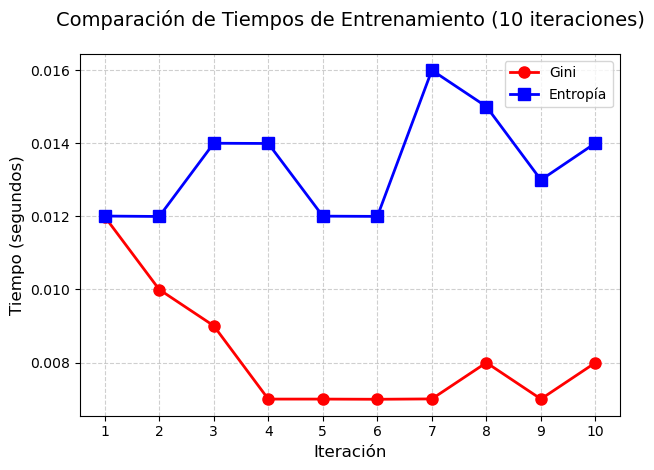

In [225]:
iteraciones = 10
entrenamientos = np.arange(1, iteraciones+1)

#1. Calculamos los tiempos para cada criterio de división
tiempos_gini = [medir_tiempo_entrenamiento('gini') for _ in range(iteraciones)]
tiempos_entropy = [medir_tiempo_entrenamiento('entropy') for _ in range(iteraciones)]

plt.plot(entrenamientos, tiempos_gini, 'r-', linewidth=2, marker='o', markersize=8, label='Gini')
plt.plot(entrenamientos, tiempos_entropy, 'b-', linewidth=2, marker='s', markersize=8, label='Entropía')


# Montamos el plot para graficas los resultados
plt.title('Comparación de Tiempos de Entrenamiento (10 iteraciones)', fontsize=14, pad=20)
plt.xlabel('Iteración', fontsize=12)
plt.ylabel('Tiempo (segundos)', fontsize=12)
plt.xticks(entrenamientos)
plt.grid(True, linestyle='--', alpha=0.6)
legend = plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

Tras correr el programa 10 veces, la entropía ha tardado más que gini en el 90 - 100% de los casos. A medida que aumentemos el tamaño del dataset, esta diferencia entre los tiempos de ejecución se agrandará aún más. 

- **Resultados del entrenamiento**: A continuación mostraremos los resultados de accuraccy y de error de cada criterio, para observar las diferencias.

In [ ]:
#2. Definimos el árbol usando GINI y lo ejecutamos
arbol_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
arbol_gini.fit(X_train, y_train)
y_pred_gini = arbol_gini.predict(X_test)
acc_gini = accuracy_score(y_test, y_pred_gini) 


#2. Definimos el árbol usando Entropía y lo ejecutamos
arbol_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
arbol_entropy.fit(X_train, y_train)
y_pred_entropy = arbol_entropy.predict(X_test)
acc_entropy = accuracy_score(y_test, y_pred_entropy)

#3. Creamos una tabla usando `tabulate` para ver las diferencias

GINI: Precisión: 0.946666666666667
GINI: Profundidad: 16  Hojas: 151
GINI: Error: 0.053333333333333

ENTROPY: Precisión: 0.961666666666667
ENTROPY: Profundidad: 12  Hojas: 134
ENTROPY: Error: 0.038333333333333


**Referencias**

https://quantdare.com/decision-trees-gini-vs-entropy/

**Enunciado:** Dibuja el modelo elegido en el punto anterior. 

**Solución**

**Enunciado:** Selecciona tres reglas que sean las que generalicen lo menos posible y otras tres que especialicen los menos posible. Interprétalas.

**Solución**

**Enunciado:** Usa tu clasificador para decidir qué tipos de crímenes ocurrirán una mañana de jueves en el distrito de Taraval. También para uno que ocurra la noche del sábado en el distrito de Park. Por último, un lunes por la mañana en el distrito Central.

**Solución**